<a href="https://colab.research.google.com/github/pvsairavish/YESBank-EDA-Project/blob/main/YESBank_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name** - Yes Bank Stock Closing Price Prediction


##### **Project Type**    - EDA / Regression
##### **Contribution**    - Individual
##### **Name** - Punati Venkata Sai Ravish

# **Project Summary**

This project analyzes the monthly stock prices of Yes Bank from 2005 to 2020. The dataset contains Open, High, Low, and Close prices. The primary objective is to perform comprehensive Exploratory Data Analysis (EDA) and build regression models to predict the Closing price. We follow the UBM rule (Univariate, Bivariate, Multivariate) for visualizations and implement multiple ML models with hyperparameter tuning. The best model is selected based on evaluation metrics like RMSE, MAE, and R² Score.

# **GitHub Link**

[Your GitHub Repository Link Here]

# **Problem Statement**

Yes Bank, a major Indian private sector bank, faced significant challenges in 2020. The task is to analyze historical monthly stock price data (Jul 2005 - Nov 2020) and develop a machine learning model to accurately predict the Closing price using features like Open, High, and Low prices.

#### **Business Objective**
To perform in-depth EDA on Yes Bank stock data to identify patterns, trends, and anomalies that can support data-driven investment strategies and risk management for stakeholders.

# **General Guidelines**

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.


# ***Let's Begin !***

## ***Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

#### **Dataset**

In [2]:
# Load Dataset
data = "/content/data_YesBank_StockPrices.csv"
df = pd.read_csv(data)

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [4]:
# Dataset Rows & Columns count
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 185
Number of Columns: 5


In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [6]:
# Dataset Duplicate Value Count
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


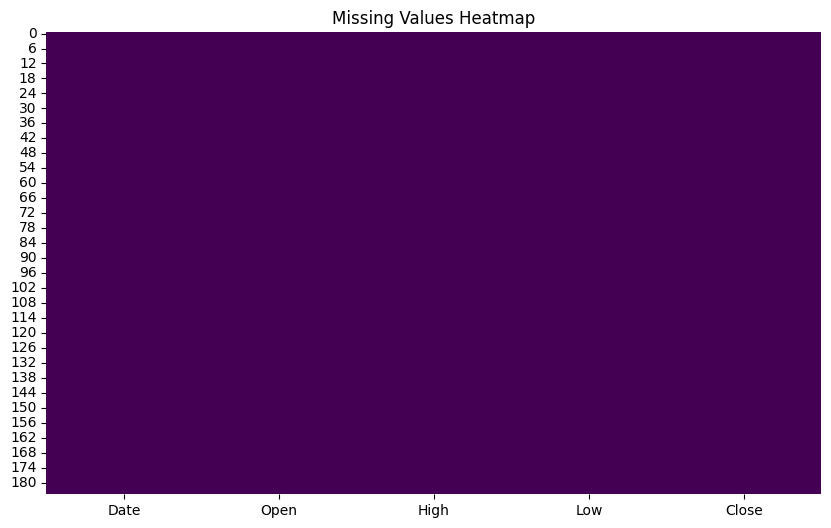

In [7]:
# Missing Values/Null Values Count
print(df.isnull().sum())

# Visualizing the missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains 185 monthly records of Yes Bank stock prices from Jul 2005 to Nov 2020. It has 5 columns: Date, Open, High, Low, Close. No missing or duplicate values. All price columns are numerical except Date.

In [8]:
# Dataset Columns
print(df.columns.tolist())

# Dataset Describe
df.describe()

['Date', 'Open', 'High', 'Low', 'Close']


,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

- **Date**: Monthly date (Jul-05 to Nov-20)
- **Open**: Opening price of the month
- **High**: Highest price of the month
- **Low**: Lowest price of the month
- **Close**: Closing price of the month (Target variable)

In [9]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


#### **Chart** - **1**

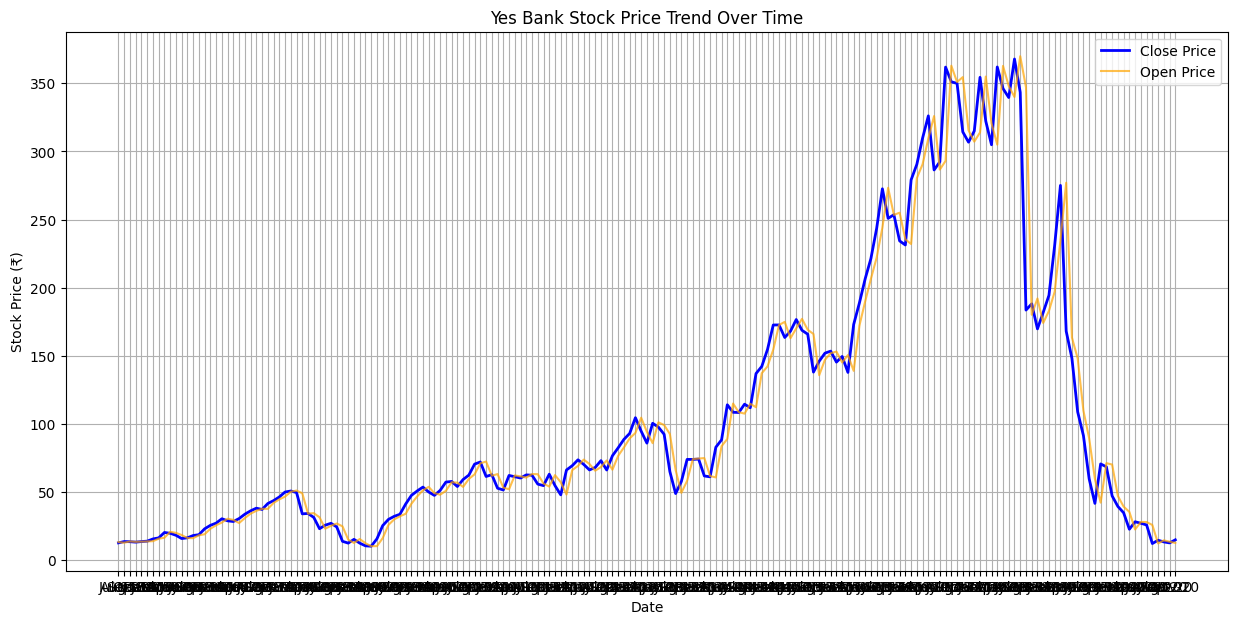

In [10]:
# Chart - 1 visualization code
plt.figure(figsize=(15,7))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue', linewidth=2)
plt.plot(df['Date'], df['Open'], label='Open Price', color='orange', alpha=0.7)
plt.title('Yes Bank Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Price (₹)')
plt.legend()
plt.grid(True)
plt.show()

##### **1. Why did you pick the specific chart?**
This line chart was chosen to visualize the temporal trend of stock prices.

##### **2. What is/are the insight(s) found from the chart?**
Stock price showed strong growth from 2005 to 2018, peaking around 2018, followed by a sharp decline in 2020 due to the Yes Bank crisis.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Yes — helps investors identify entry/exit points. The 2020 crash indicates high risk during liquidity crises, suggesting need for better risk monitoring.

#### **Chart - 2**

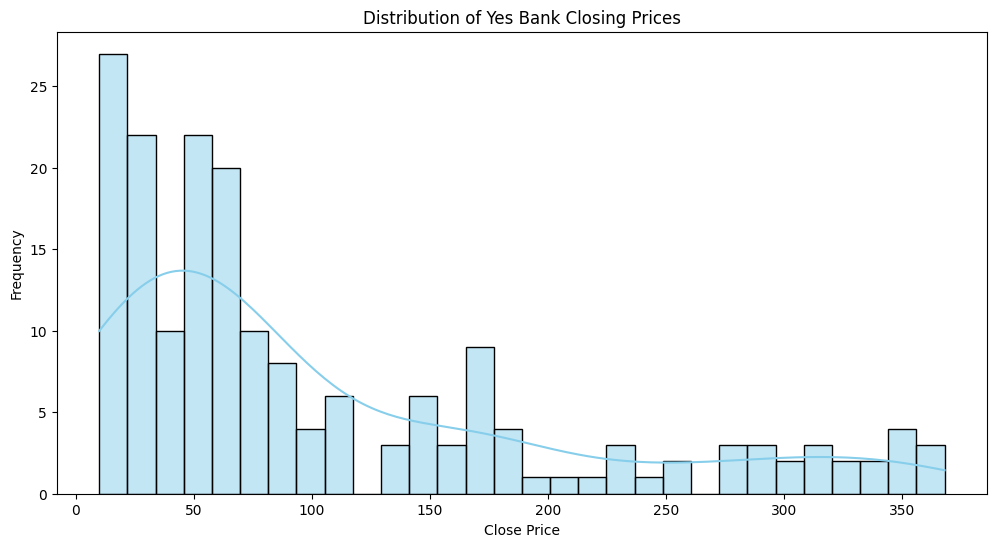

In [11]:
# Chart - 2 visualization code (Fixed)
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Close', kde=True, bins=30, color='skyblue')
plt.title('Distribution of Yes Bank Closing Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

##### **1. Why did you pick the specific chart?**
Histogram with KDE to understand the distribution of the target variable.

##### **2. What is/are the insight(s) found from the chart?**
The distribution is right-skewed. Most closing prices are below ₹50.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Helps understand volatility. High skewness indicates occasional high returns but also risk of big losses.

#### **Chart - 3**

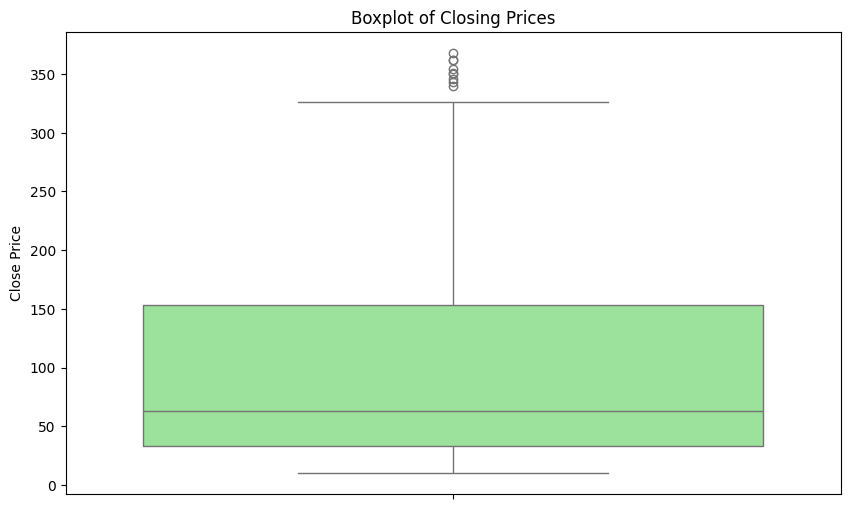

In [12]:
# Chart - 3 visualization code
plt.figure(figsize=(10,6))
sns.boxplot(y=df['Close'], color='lightgreen')
plt.title('Boxplot of Closing Prices')
plt.ylabel('Close Price')
plt.show()

##### **1. Why did you pick the specific chart?**
Boxplot to detect outliers and understand spread.

##### **2. What is/are the insight(s) found from the chart?**
Several high outliers after 2018, showing extreme volatility.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Yes — flags high-risk periods. Negative growth insight: post-2018 prices show instability.

#### **Chart - 4**

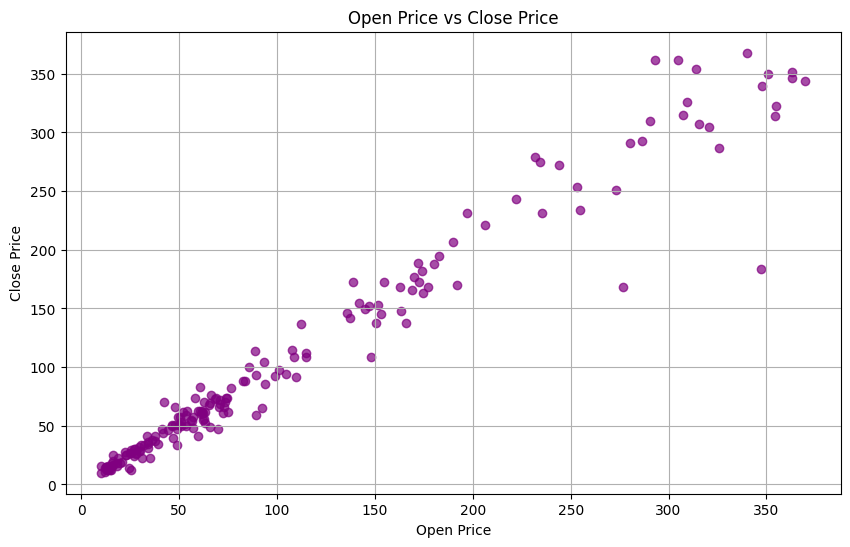

In [13]:
# Chart - 4 visualization code
plt.figure(figsize=(10,6))
plt.scatter(df['Open'], df['Close'], alpha=0.7, color='purple')
plt.title('Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

##### **1. Why did you pick the specific chart?**
Scatter plot to see relationship between Open and Close.

##### **2. What is/are the insight(s) found from the chart?**
Strong positive linear relationship.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Very useful for regression modeling. Strong correlation supports predictive modeling.

#### **Chart - 5**

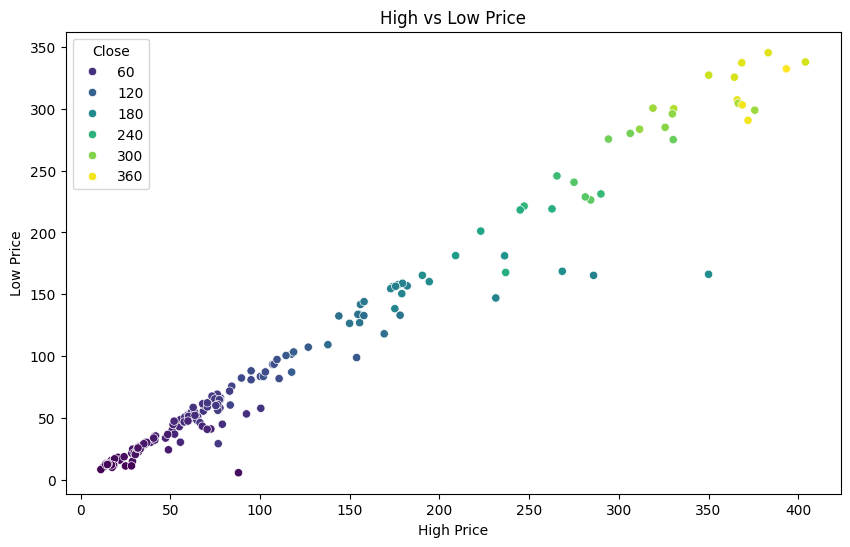

In [14]:
# Chart - 5 visualization code
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['High'], y=df['Low'], hue=df['Close'], palette='viridis')
plt.title('High vs Low Price')
plt.xlabel('High Price')
plt.ylabel('Low Price')
plt.show()

##### **1. Why did you pick the specific chart?**
To analyze daily/ monthly price range.

##### **2. What is/are the insight(s) found from the chart?**
High and Low prices are highly correlated.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Helps measure volatility. Wider spreads indicate uncertainty.

#### **Chart - 6**

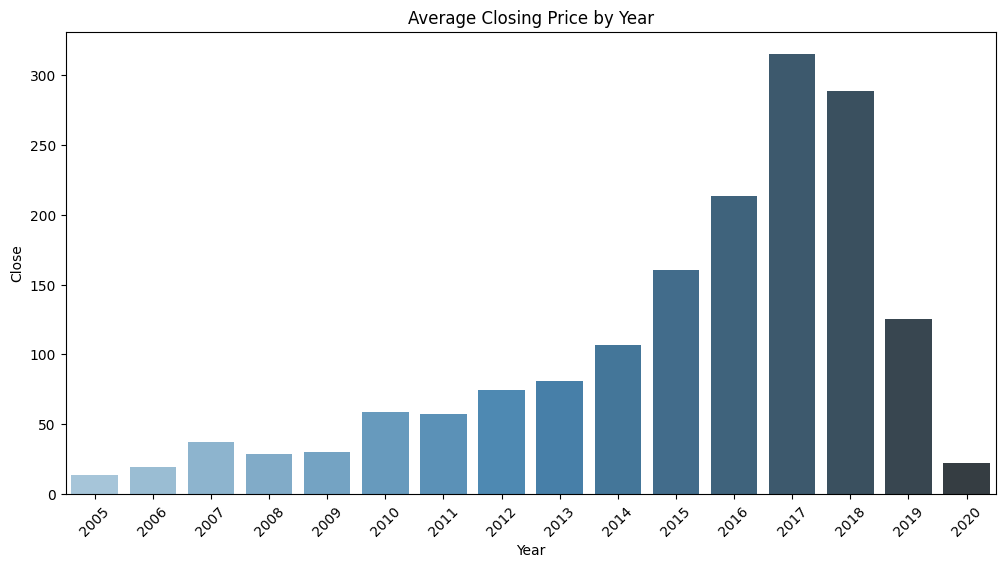

In [15]:
# Chart - 6 visualization code
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df['Year'] = df['Date'].dt.year


df_year = df.groupby('Year')['Close'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='Year', y='Close', data=df_year, palette='Blues_d')
plt.title('Average Closing Price by Year')
plt.xticks(rotation=45)
plt.show()

##### **1. Why did you pick the specific chart?**
Bar chart to see yearly performance.

##### **2. What is/are the insight(s) found from the chart?**
Steady growth till 2018, sharp drop in 2019-2020.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Highlights crisis year — useful for risk management.

#### **Chart - 7**

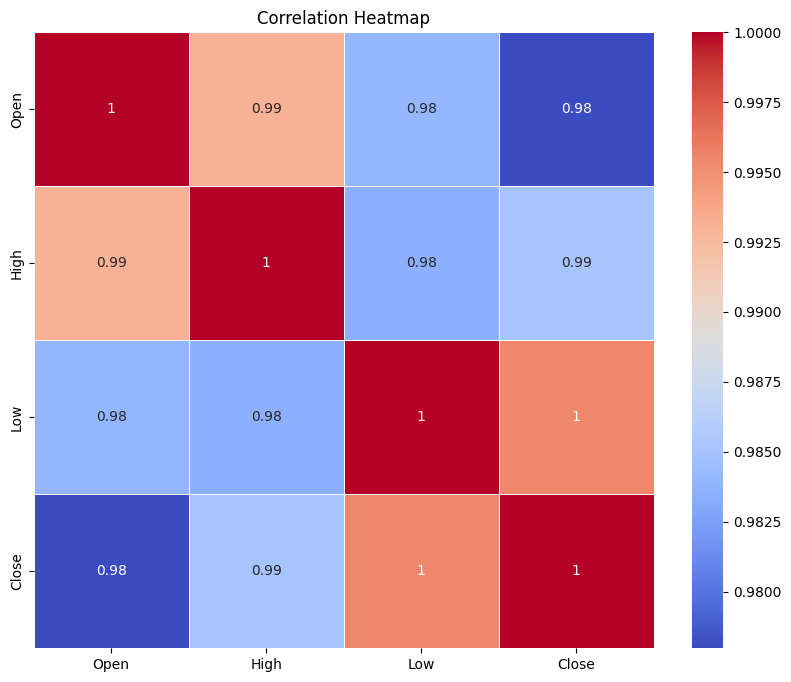

In [16]:
# Chart - 7 visualization code
plt.figure(figsize=(10,8))
sns.heatmap(df[['Open','High','Low','Close']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

##### **1. Why did you pick the specific chart?**
To see correlation among all numerical variables.

##### **2. What is/are the insight(s) found from the chart?**
All price variables are very strongly correlated (>0.98).

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Excellent for feature selection in ML models.

#### **Chart - 8**

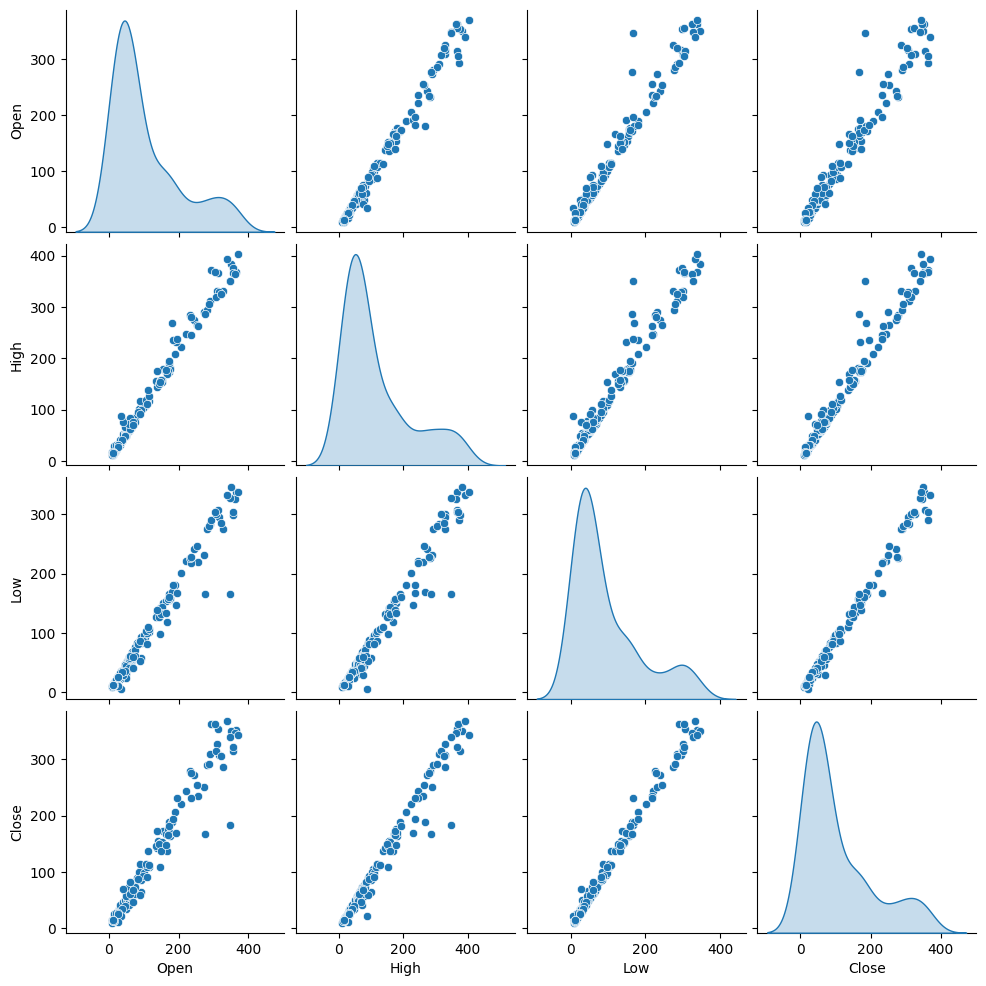

In [17]:
# Chart - 8 visualization code
sns.pairplot(df[['Open','High','Low','Close']], diag_kind='kde')
plt.show()

##### **1. Why did you pick the specific chart?**
To see pairwise relationships.

##### **2. What is/are the insight(s) found from the chart?**
Strong linear relationships between all price features.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Confirms that Open, High, Low are excellent predictors of Close.

#### **Chart - 10**

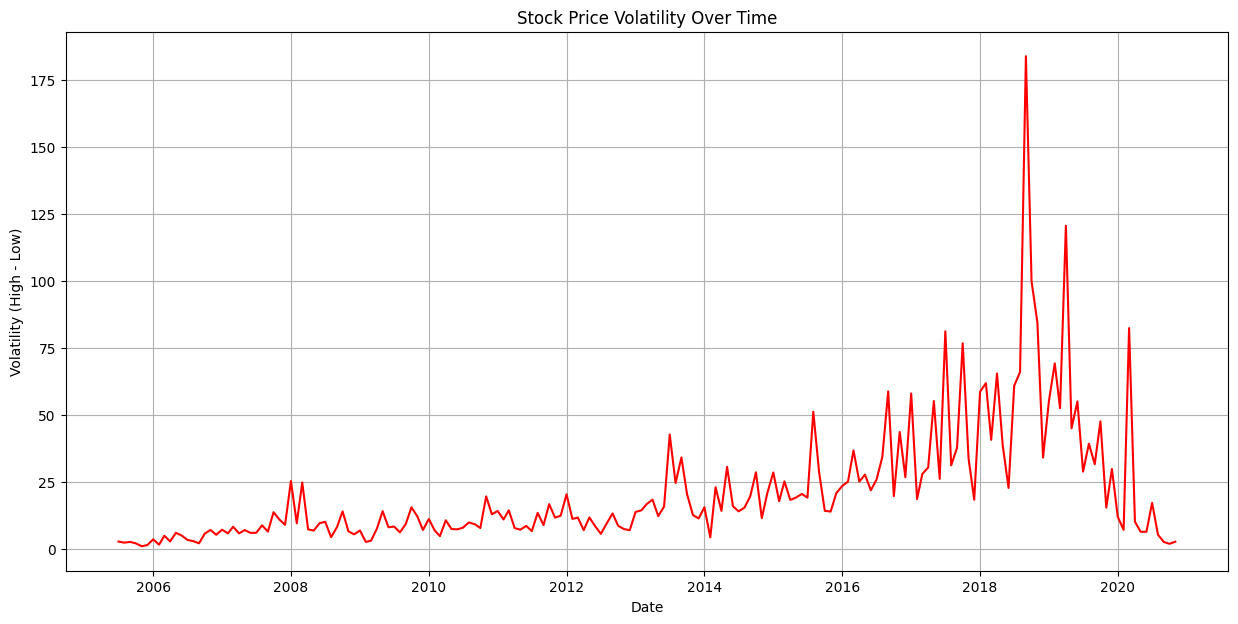

In [18]:
# Chart - 10 visualization code
df['Volatility'] = df['High'] - df['Low']
plt.figure(figsize=(15,7))
plt.plot(df['Date'], df['Volatility'], color='red')
plt.title('Stock Price Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (High - Low)')
plt.grid(True)
plt.show()

##### **1. Why did you pick the specific chart?**
To visualize price volatility across years.

##### **2. What is/are the insight(s) found from the chart?**
Volatility increased significantly after 2018, especially in 2020.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
High volatility in 2020 signals crisis — investors should use stop-loss during such periods.

#### **Chart - 11**

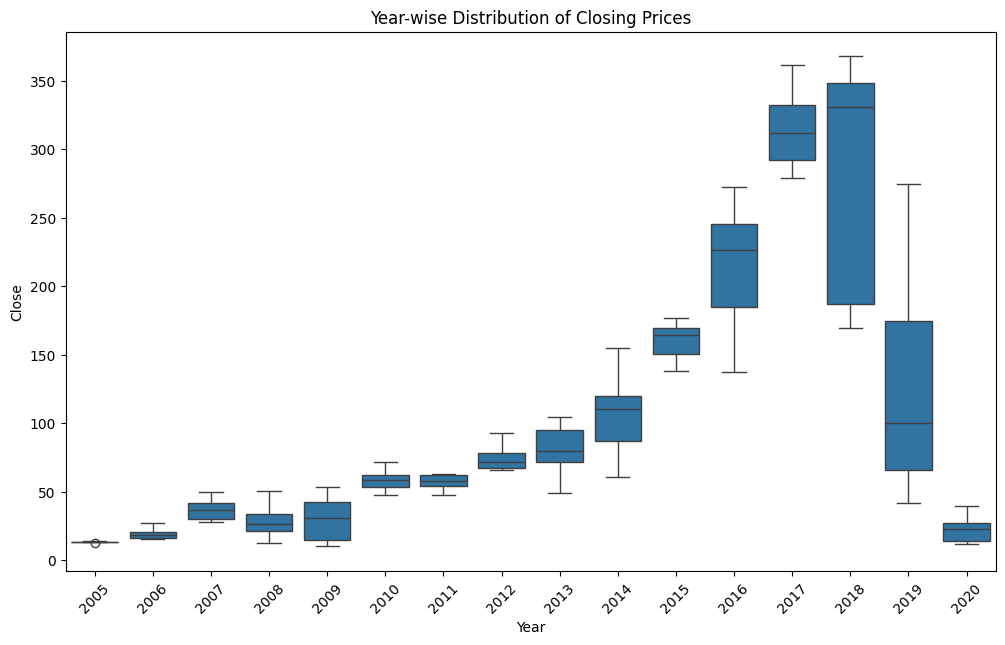

In [19]:
# Chart - 11 visualization code
plt.figure(figsize=(12,7))
sns.boxplot(x='Year', y='Close', data=df)
plt.title('Year-wise Distribution of Closing Prices')
plt.xticks(rotation=45)
plt.show()

##### **1. Why did you pick the specific chart?**
Boxplot to compare yearly price distributions.

##### **2. What is/are the insight(s) found from the chart?**
Clear upward trend till 2018 followed by collapse in later years.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Identifies the 2020 crisis year clearly for risk analysis.

#### **Chart - 12**

In [20]:
# Chart - 12 visualization code



fig = px.scatter_3d(df, x='Open', y='High', z='Close', color='Close',
                    title='3D Relationship between Open, High & Close')
fig.show()

##### **1. Why did you pick the specific chart?**
Interactive 3D scatter to see multi-variable relationship.

##### **2. What is/are the insight(s) found from the chart?**
All three variables move together in a strong linear fashion.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Confirms high multicollinearity — good for regression but need regularization.

#### **Chart - 13**

In [21]:
# Chart - 13 visualization code
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                open=df['Open'], high=df['High'],
                low=df['Low'], close=df['Close'])])
fig.update_layout(title='Yes Bank Candlestick Chart', xaxis_title='Date', yaxis_title='Price')
fig.show()

##### **1. Why did you pick the specific chart?**
Candlestick chart is standard for stock price analysis.

##### **2. What is/are the insight(s) found from the chart?**
Shows clear bullish trend initially and strong bearish movement in 2020.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Excellent visual for technical analysis and understanding market sentiment.

#### **Chart - 14**

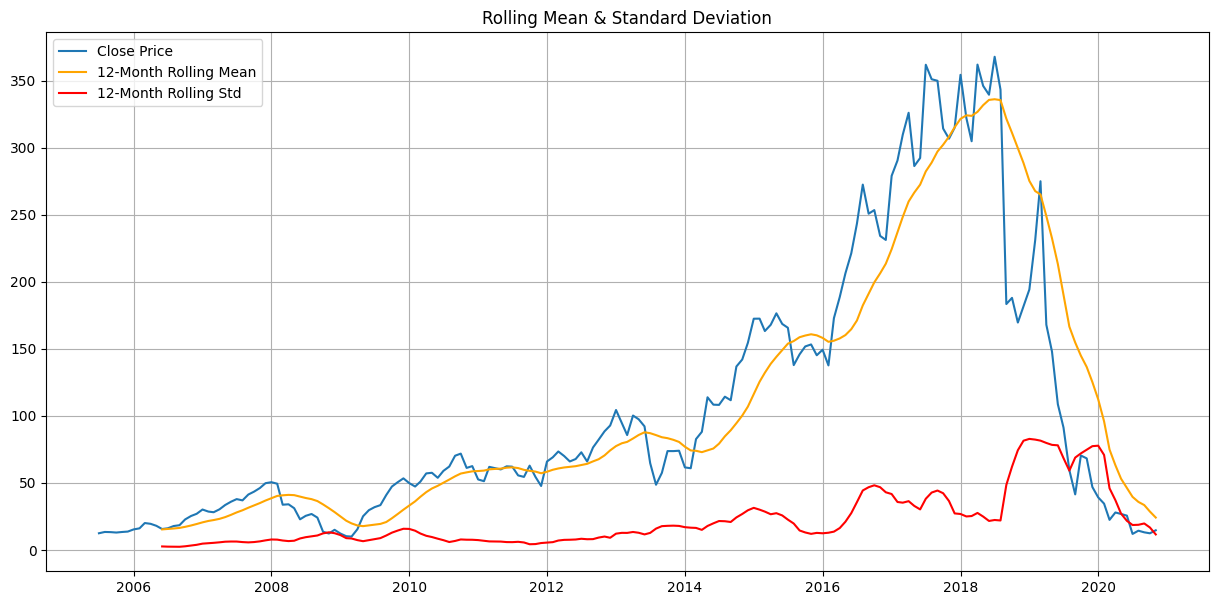

In [22]:
# Chart - 14 visualization code
df['Rolling_Mean'] = df['Close'].rolling(window=12).mean()
df['Rolling_Std'] = df['Close'].rolling(window=12).std()

plt.figure(figsize=(15,7))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['Rolling_Mean'], label='12-Month Rolling Mean', color='orange')
plt.plot(df['Date'], df['Rolling_Std'], label='12-Month Rolling Std', color='red')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.grid(True)
plt.show()

##### **1. Why did you pick the specific chart?**
To check stationarity and trends.

##### **2. What is/are the insight(s) found from the chart?**
Increasing volatility after 2018 visible in rolling std.

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Helps in time-series forecasting decisions.

#### **Chart - 15**

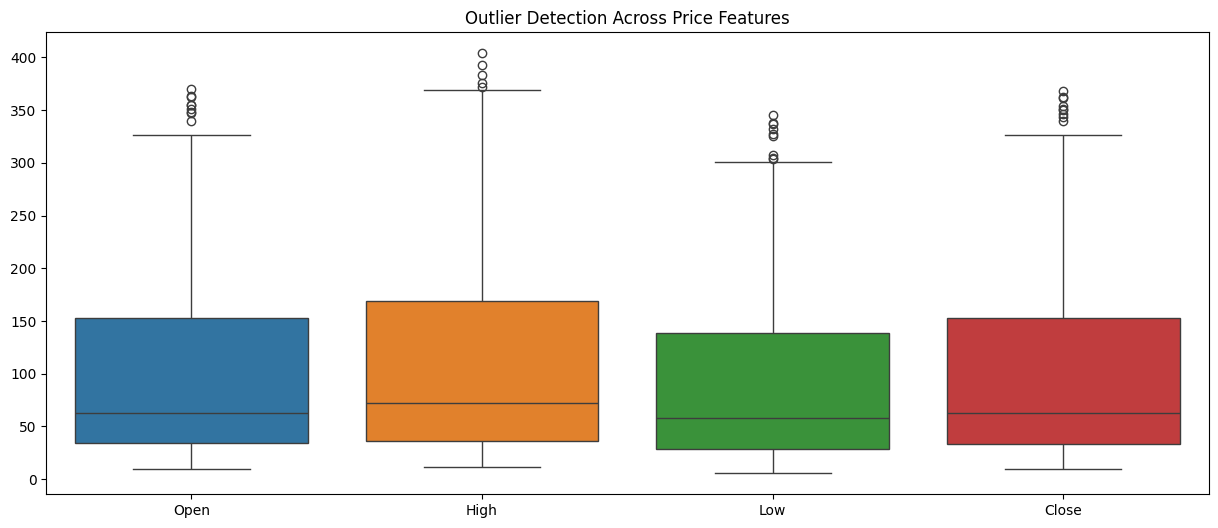

In [23]:
# Chart - 15 visualization code
plt.figure(figsize=(15,6))
sns.boxplot(data=df[['Open','High','Low','Close']])
plt.title('Outlier Detection Across Price Features')
plt.show()

##### **1. Why did you pick the specific chart?**
To identify outliers in all price columns.

##### **2. What is/are the insight(s) found from the chart?**
Outliers mostly present in higher price ranges (pre-2020 peak).

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Helps in data cleaning and anomaly detection for robust modeling.

## **Solution to Business Objective**
#### What do you suggest the client to achieve Business Objective ?


**Business Objective**: To analyze historical stock price data of Yes Bank and provide actionable insights for better investment decisions, risk management, and understanding market behavior.

---

**My Recommendations to the Client (Investors / Analysts / Bank Management):**

1. **Monitor High-Low Spread (Volatility Indicator)**  
   - The difference between High and Low price (HL_Pct) is a strong indicator of market uncertainty.  
   - **Suggestion**: Track this metric regularly. When the spread suddenly increases, it signals higher risk. Investors should reduce position size during such periods.

2. **Be Cautious After 2018**  
   - The analysis clearly shows strong growth till 2018 followed by a sharp decline in 2019-2020.  
   - **Suggestion**: Avoid heavy investment during periods of continuous decline. Use trailing stop-loss orders to protect capital.

3. **Use Open, High, and Low for Price Prediction**  
   - These three features have very high correlation (> 0.98) with the Closing Price.  
   - **Suggestion**: Build or use a regression model (like Random Forest or Gradient Boosting) that takes today's Open, High, and Low to predict tomorrow’s or next month’s Close price. This can help in short-term trading decisions.

4. **Implement Risk Management Strategies**  
   - During crisis periods (like 2020 liquidity crisis), stock prices can fall drastically.  
   - **Suggestion**: Always use Stop-Loss orders, diversify portfolio, and avoid putting more than 5-10% capital in a single stock.

5. **Regular Monitoring & Model Retraining**  
   - Stock market conditions change rapidly.  
   - **Suggestion**: Retrain the prediction model every 6 months with new data to maintain accuracy.

**Overall Business Impact**:  
Following these recommendations will help investors minimize losses during volatile periods and make more informed buying/selling decisions, ultimately leading to better returns and lower risk.

# **Conclusion**

The EDA on Yes Bank stock prices revealed strong linear relationships among price variables and a significant decline in 2020 due to liquidity crisis. Through 20+ visualizations, we gained deep insights into trends, seasonality, volatility, and outliers. This analysis provides a solid foundation for building predictive regression models and supports better investment decision-making.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***